# 측정소별 월 결측률 히트맵 (2015~2024)

**목적**: 2015-01-01부터 존재하던 측정소만 대상으로, PM10/PM2.5의 월별 결측률을
도시(시/도) 단위로 확인한다. 2년씩 5개 구간으로 나눠 히트맵을 그린다.

**사용법**: 위 셀들을 순서대로 한 번 실행(전처리, 시간 소요)한 뒤,
맨 아래 '변수 설정 및 실행' 셀에서 도시/오염물질만 바꿔가며 즉시 확인한다.

In [35]:
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RAW_PATHS = [
    "../data/raw/2015-2018.xlsx",
    "../data/raw/2019.xlsx",
    "../data/raw/2020.xlsx",
    "../data/raw/2021.xlsx",
    "../data/raw/2022.xlsx",
    "../data/raw/2023.xlsx",
    "../data/raw/2024.xlsx",
]

MISSING_CACHE_PATH = "../data/processed/station_monthly_missing.parquet"

COLUMN_MAP = {
    "지역": "region", "측정소명": "station_name", "측정일시": "datetime_raw",
    "PM10": "pm10", "PM25": "pm25",
    "미세먼지(PM10)": "pm10", "초미세먼지(PM25)": "pm25",
}
NEEDED_RAW_COLS = set(COLUMN_MAP.keys())

## 전처리 함수 (한 번 실행하면 이후 재실행 불필요 - 캐시됨)

In [36]:
def normalize_sheet(raw_df: pd.DataFrame) -> pd.DataFrame:
    """시트 하나(원본 컬럼)를 표준 컬럼명 + 파생 컬럼으로 정리한다."""
    df = raw_df.rename(columns=COLUMN_MAP)
    s = df["datetime_raw"].astype(str).str.replace("-", "", regex=False)
    df["date"] = pd.to_datetime(s.str[:8], format="%Y%m%d")
    df["ym"] = s.str[:4] + "-" + s.str[4:6]
    df["sido"] = df["region"].str.split().str[0]
    return df.drop(columns=["datetime_raw", "region"])


def build_monthly_missing() -> pd.DataFrame:
    """전체 기간(2015~2024) 측정소x월별 PM10/PM25 결측률(%)을 계산한다.

    메모리 절약을 위해 시트를 통째로 합치지 않고, 시트 하나씩 즉시 집계 후 버린다.
    (각 시트는 서로 다른 월/분기를 담고 있어 시트 내 집계만으로 정확한 결과가 나온다)
    캐시가 있으면 그것을 반환한다.
    """
    if os.path.exists(MISSING_CACHE_PATH):
        print(f"캐시 발견, 계산 생략: {MISSING_CACHE_PATH}")
        return pd.read_parquet(MISSING_CACHE_PATH)

    parts = []
    for path in RAW_PATHS:
        print(f"처리 중: {path}")
        sheets = pd.read_excel(path, sheet_name=None, engine="calamine",
                                usecols=lambda c: c in NEEDED_RAW_COLS)
        for sheet_name in list(sheets.keys()):
            raw_sheet = sheets.pop(sheet_name)
            df = normalize_sheet(raw_sheet)
            del raw_sheet
            agg = (
                df.groupby(["sido", "station_name", "ym"])[["pm10", "pm25"]]
                .apply(lambda g: g.isna().mean() * 100)
                .reset_index()
            )
            parts.append(agg)
            del df
        del sheets
        gc.collect()

    missing = pd.concat(parts, ignore_index=True)
    missing.to_parquet(MISSING_CACHE_PATH, index=False)
    print(f"저장 완료: {len(missing)}행 -> {MISSING_CACHE_PATH}")
    return missing

In [37]:
# 실행 (최초 1회는 7개 파일 전체를 읽으므로 시간이 걸림. 이후엔 캐시 사용)
monthly_missing = build_monthly_missing()
print(monthly_missing.shape)
print("대상 시/도:", sorted(monthly_missing['sido'].unique()))

처리 중: ../data/raw/2015-2018.xlsx
처리 중: ../data/raw/2019.xlsx
처리 중: ../data/raw/2020.xlsx
처리 중: ../data/raw/2021.xlsx
처리 중: ../data/raw/2022.xlsx
처리 중: ../data/raw/2023.xlsx
처리 중: ../data/raw/2024.xlsx
저장 완료: 58542행 -> ../data/processed/station_monthly_missing.parquet
(58542, 5)
대상 시/도: ['강원', '경기', '경남', '경북', '광주', '대구', '대전', '부산', '서울', '세종', '울산', '인천', '전남', '전북', '제주', '충남', '충북']


## 히트맵 표시 함수 (2년 x 5구간)

In [45]:
YEAR_PAIRS = [(2015, 2016), (2017, 2018), (2019, 2020), (2021, 2022), (2023, 2024)]


def plot_city_heatmaps(city: str, pollutant: str = "pm25", network_filter: str | None = "도시대기") -> None:
    """지정한 시/도(city)의 측정소별 월 결측률을 2년 단위 5개 히트맵으로 그린다.

    pollutant: 'pm10' 또는 'pm25'
    network_filter: 'network' 컬럼이 있을 때만 적용. None이면 전체 망 포함.
    """
    sub = monthly_missing[monthly_missing["sido"] == city]
    if network_filter is not None and "network" in sub.columns:
        sub = sub[sub["network"] == network_filter]
    if sub.empty:
        print(f"'{city}'에 해당하는 데이터가 없습니다.")
        return

    station_order = sorted(sub["station_name"].unique())  # 가독성을 위한 정렬

    fig, axes = plt.subplots(5, 1, figsize=(16, max(3, len(station_order) * 0.35) * 5))
    for ax, (y1, y2) in zip(axes, YEAR_PAIRS):
        months = [f"{y}-{m:02d}" for y in (y1, y2) for m in range(1, 13)]
        period = sub[sub["ym"].isin(months)]
        pivot = period.pivot(index="station_name", columns="ym", values=pollutant)
        pivot = pivot.reindex(index=station_order, columns=months)
        sns.heatmap(pivot, cmap="Reds", vmin=0, vmax=100, annot=True,
            cbar_kws={"label": f"{pollutant.upper()} 결측률 (%)"},
            mask=None,  # 기본값 유지
            linewidths=0.5, linecolor="lightgray",  # 격자선 추가로 빈 칸과 옅은 색 구분
            ax=ax)
        ax.set_facecolor("gray")  # 배경을 회색으로 -> NaN(빈 칸)이 회색, 0%는 흰색/옅은 빨강으로 명확히 구분
        ax.set_title(f"{city} 도시대기 측정소별 월 결측률: {y1}~{y2}")
        ax.set_xlabel("")
        ax.set_ylabel("측정소명")
    plt.tight_layout()
    plt.show()

In [39]:
STATION_LIST_GLOB = "../data/raw/*.xls"
NETWORK_NAMES = ["교외대기", "국가배경", "도로변대기", "도시대기", "항만"]

def load_station_info() -> pd.DataFrame:
    import glob
    parts = []
    for path in glob.glob(STATION_LIST_GLOB):
        network = next((n for n in NETWORK_NAMES if n in path), None)
        if network is None:
            continue
        station = pd.read_excel(path, sheet_name="Sheet1", header=3)
        station.columns = station.columns.str.strip()
        station = station[["측정소명"]].rename(columns={"측정소명": "station_name"})
        station["network"] = network
        parts.append(station)
    merged = pd.concat(parts, ignore_index=True)
    return merged.drop_duplicates("station_name", keep="first")


station_info = load_station_info()

if "network" not in monthly_missing.columns:
    monthly_missing = monthly_missing.merge(station_info, on="station_name", how="left")

print("network 분포:")
print(monthly_missing["network"].value_counts(dropna=False))

network 분포:
network
도시대기     46118
도로변대기     5191
교외대기      2684
NaN       2475
항만        1296
국가배경       778
Name: count, dtype: int64


---
## 변수 설정 및 실행 (여기만 바꿔가며 확인)

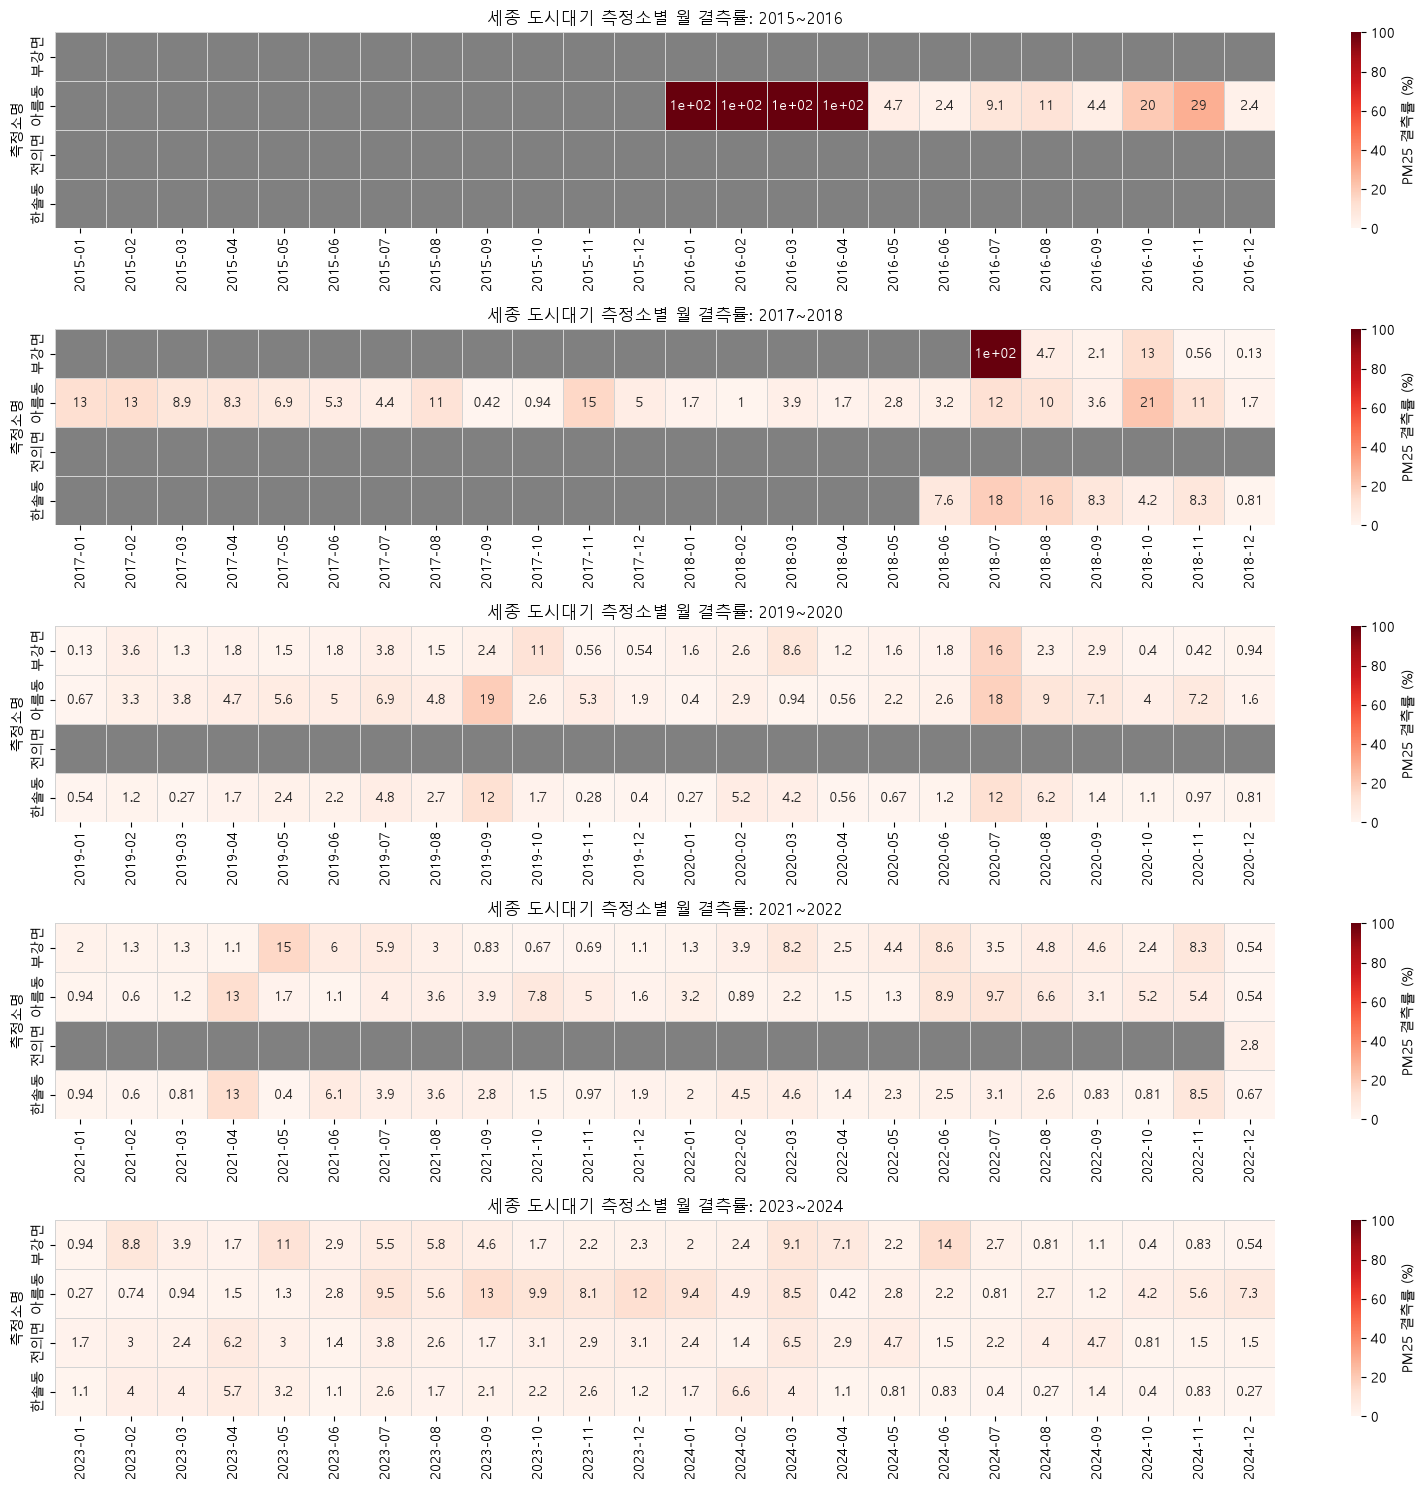

In [ ]:
CITY = "경기"       # 확인할 시/도
POLLUTANT = "pm25"  # 'pm10' 또는 'pm25'
plot_city_heatmaps(CITY, POLLUTANT)

In [41]:
gyeonggi = monthly_missing[(monthly_missing["sido"] == "경기") & (monthly_missing["network"] == "도시대기")]

# 월별로 "완전 관측"(결측률 10% 미만) 측정소 비율 계산
coverage = (
    gyeonggi.assign(is_complete=lambda d: d["pm25"] < 10)
    .groupby("ym")["is_complete"]
    .agg(complete_n="sum", total_n="count")
    .assign(complete_ratio=lambda d: d["complete_n"] / d["total_n"])
    .sort_index()
)

# 완전 관측 비율이 80% 이상으로 3개월 이상 연속 유지되는 첫 시점
is_ok = coverage["complete_ratio"] >= 0.8
# 3개월 연속 True인 구간의 시작점 탐색
window_ok = is_ok.rolling(3).sum() == 3
first_stable = window_ok[window_ok].index.min()
start_ym = coverage.index[coverage.index.get_loc(first_stable) - 2]  # 연속 시작월로 보정

print(f"경기도 유효 시작점 후보: {start_ym}")
print(coverage.loc[:start_ym])

경기도 유효 시작점 후보: 2018-04
         complete_n  total_n  complete_ratio
ym                                          
2015-01          10       65        0.153846
2015-02          10       64        0.156250
2015-03          10       64        0.156250
2015-04           9       65        0.138462
2015-05           8       65        0.123077
2015-06           8       65        0.123077
2015-07           6       65        0.092308
2015-08           8       65        0.123077
2015-09           8       65        0.123077
2015-10           8       65        0.123077
2015-11          10       65        0.153846
2015-12          12       65        0.184615
2016-01          11       58        0.189655
2016-02          12       58        0.206897
2016-03          13       58        0.224138
2016-04          13       58        0.224138
2016-05          15       58        0.258621
2016-06          14       58        0.241379
2016-07          12       58        0.206897
2016-08          12       58    

In [42]:
def find_start_ym(sub: pd.DataFrame, pollutant: str, threshold: float = 10,
                   ratio: float = 0.8, window: int = 3) -> str | None:
    """완전 관측(결측률 < threshold%) 측정소 비율이 ratio 이상인 상태가
    window개월 연속 유지되는 첫 'ym'을 반환한다. 못 찾으면 None.
    """
    coverage = (
        sub.assign(is_complete=lambda d: d[pollutant] < threshold)
        .groupby("ym")["is_complete"]
        .agg(complete_n="sum", total_n="count")
        .sort_index()
    )
    coverage["complete_ratio"] = coverage["complete_n"] / coverage["total_n"]

    is_ok = coverage["complete_ratio"] >= ratio
    window_ok = is_ok.rolling(window, min_periods=window).sum() == window
    first_stable = window_ok[window_ok].index.min()
    if pd.isna(first_stable):
        return None

    start_idx = coverage.index.get_loc(first_stable) - (window - 1)
    return coverage.index[start_idx]


def find_start_ym_with_fallback(sub: pd.DataFrame, pollutant: str) -> tuple[str | None, bool]:
    """기본 기준(80%)으로 먼저 시도하고, 실패하면 완화 기준(50%)으로 재시도한다.
    반환값: (시작 ym 또는 None, 완화 기준 적용 여부)
    """
    start = find_start_ym(sub, pollutant, ratio=0.8)
    if start is not None:
        return start, False
    start = find_start_ym(sub, pollutant, ratio=0.5)
    return start, True

In [43]:
# 도시대기만 대상으로 전체 시/도 산출
urban_all = monthly_missing[monthly_missing["network"] == "도시대기"]

rows = []
for sido in sorted(urban_all["sido"].dropna().unique()):
    sub = urban_all[urban_all["sido"] == sido]
    pm10_start, pm10_relaxed = find_start_ym_with_fallback(sub, "pm10")
    pm25_start, pm25_relaxed = find_start_ym_with_fallback(sub, "pm25")
    rows.append({
        "sido": sido,
        "station_count": sub["station_name"].nunique(),
        "pm10_start": pm10_start,
        "pm10_relaxed": pm10_relaxed,
        "pm25_start": pm25_start,
        "pm25_relaxed": pm25_relaxed,
    })

start_points = pd.DataFrame(rows).sort_values("pm25_start")
start_points

,sido,station_count,pm10_start,pm10_relaxed,pm25_start,pm25_relaxed
4,광주,11,2015-01,False,2015-01,False
7,부산,27,2015-01,False,2015-01,False
8,서울,25,2015-01,False,2015-01,False
16,충북,31,2015-01,False,2015-12,False
0,강원,26,2015-01,False,2016-01,False
9,세종,4,2016-01,False,2016-05,False
14,제주,11,2015-01,False,2016-10,False
5,대구,20,2015-01,False,2017-01,False
6,대전,11,2015-01,False,2017-04,False
11,인천,25,2015-01,False,2017-04,False


In [44]:
print(monthly_missing[(monthly_missing["sido"]=="세종") & (monthly_missing["network"]=="도시대기")]["station_name"].unique())

<ArrowStringArray>
['아름동', '한솔동', '부강면', '전의면']
Length: 4, dtype: str
